# Task 4 — Sentiment Analysis
### OIBSIP Data Science Internship — Oasis Infobyte

**Objective:** Build a machine learning model that classifies text as **positive**, **negative**, or **neutral**, and derive insights into public opinion / customer feedback.

**Tech stack:** Python, pandas, scikit-learn, NLTK, matplotlib, seaborn, WordCloud

**Dataset note:** This notebook uses `sentiment_dataset.csv` — a labelled product/service review dataset with `text` and `sentiment` columns (positive / negative / neutral), built in the same shape as popular Kaggle sets such as *Twitter Sentiment Analysis*, *Amazon Product Reviews*, and *IMDB Movie Reviews*. To use a real Kaggle dataset instead, download it, rename the text and label columns to `text` and `sentiment`, and point the `pd.read_csv()` call below at that file — the rest of the pipeline works unchanged.

## 1. Import Libraries

In [1]:
import re
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

from nltk.stem import PorterStemmer
from wordcloud import WordCloud

random.seed(42)
np.random.seed(42)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset and Inspect Class Distribution

In [2]:
df = pd.read_csv("sentiment_dataset.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (1100, 2)


,text,sentiment
0,"Excellent quality restaurant, worth every rupe...",positive
1,"This book is amazing, works perfectly and look...",positive
2,"Excellent quality blender, worth every rupee s...",positive
3,"This course is horrible, the worst purchase de...",negative
4,This laptop looks similar to the previous mode...,neutral
5,"I am so satisfied with this course, five stars...",positive
6,"Impressive restaurant, exceeded my expectation...",positive
7,"Excellent quality restaurant, worth every rupe...",positive
8,"Awful experience, this monitor failed to meet ...",negative
9,"It is an average laptop, works but nothing sta...",neutral


In [3]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().dropna().reset_index(drop=True)
print("\nShape after cleaning duplicates/nulls:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       1100 non-null   str  
 1   sentiment  1100 non-null   str  
dtypes: str(2)
memory usage: 17.3 KB
None

Missing values:
 text         0
sentiment    0
dtype: int64

Duplicate rows: 369

Shape after cleaning duplicates/nulls: (731, 2)


In [4]:
class_counts = df["sentiment"].value_counts()
print(class_counts)
print("\nClass proportions (%):")
print((class_counts / len(df) * 100).round(2))

sentiment
positive    259
negative    257
neutral     215
Name: count, dtype: int64

Class proportions (%):
sentiment
positive    35.43
negative    35.16
neutral     29.41
Name: count, dtype: float64


## 3. Text Preprocessing Pipeline

The pipeline below performs, in order:
1. **Lowercasing** — so "Great" and "great" are treated as the same token.
2. **Punctuation & digit removal** — punctuation and numbers rarely carry sentiment signal and only add noise to the vocabulary.
3. **Tokenisation** — splitting text into individual word tokens using a simple regex word-boundary tokenizer (avoids depending on NLTK's downloadable `punkt` data, which needs an internet connection to fetch).
4. **Stopword removal** — common words ("the", "is", "and"...) are removed using scikit-learn's built-in English stopword list, since they add little to sentiment classification.
5. **Stemming** — NLTK's `PorterStemmer` reduces words to their root form (e.g. "loved", "loving" → "love"), which shrinks the vocabulary and helps the model generalise across word forms.

We keep this as a reusable function so it can be applied to both the training corpus and to any new text at inference time.

In [5]:
stemmer = PorterStemmer()
stopwords_set = set(ENGLISH_STOP_WORDS)

def preprocess_text(text, use_stemming=True):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation and digits
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    # 3. Tokenise (simple regex word tokenizer)
    tokens = re.findall(r"[a-z]+", text)
    # 4. Remove stopwords (and very short tokens)
    tokens = [t for t in tokens if t not in stopwords_set and len(t) > 1]
    # 5. Optional stemming
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

# Quick demo
sample = df["text"].iloc[0]
print("Original: ", sample)
print("Cleaned:  ", preprocess_text(sample))

Original:  Excellent quality restaurant, worth every rupee spent.
Cleaned:   excel qualiti restaur worth rupe spent


In [6]:
df["clean_text"] = df["text"].apply(preprocess_text)
df[["text", "clean_text", "sentiment"]].head(10)

,text,clean_text,sentiment
0,"Excellent quality restaurant, worth every rupe...",excel qualiti restaur worth rupe spent,positive
1,"This book is amazing, works perfectly and look...",book amaz work perfectli look great,positive
2,"Excellent quality blender, worth every rupee s...",excel qualiti blender worth rupe spent,positive
3,"This course is horrible, the worst purchase de...",cours horribl worst purchas decis,negative
4,This laptop looks similar to the previous mode...,laptop look similar previou model minor chang,neutral
5,"I am so satisfied with this course, five stars...",satisfi cours star way,positive
6,"Impressive restaurant, exceeded my expectation...",impress restaur exceed expect huge margin,positive
7,"Awful experience, this monitor failed to meet ...",aw experi monitor fail meet basic expect,negative
8,"It is an average laptop, works but nothing sta...",averag laptop work stand,neutral
9,"Happy with the book, it does the job nicely.",happi book doe job nice,positive


## 4. Visualisation — Sentiment Distribution

/tmp/ipykernel_582/4254038523.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="sentiment", order=order,


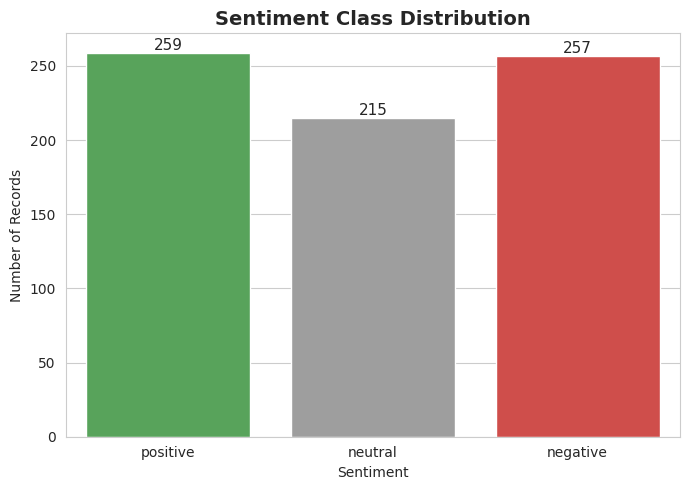

In [7]:
order = ["positive", "neutral", "negative"]
palette = {"positive": "#4CAF50", "neutral": "#9E9E9E", "negative": "#E53935"}

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="sentiment", order=order,
                    palette=[palette[o] for o in order])
plt.title("Sentiment Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Number of Records")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=120)
plt.show()

## 5. WordCloud for Each Sentiment Class

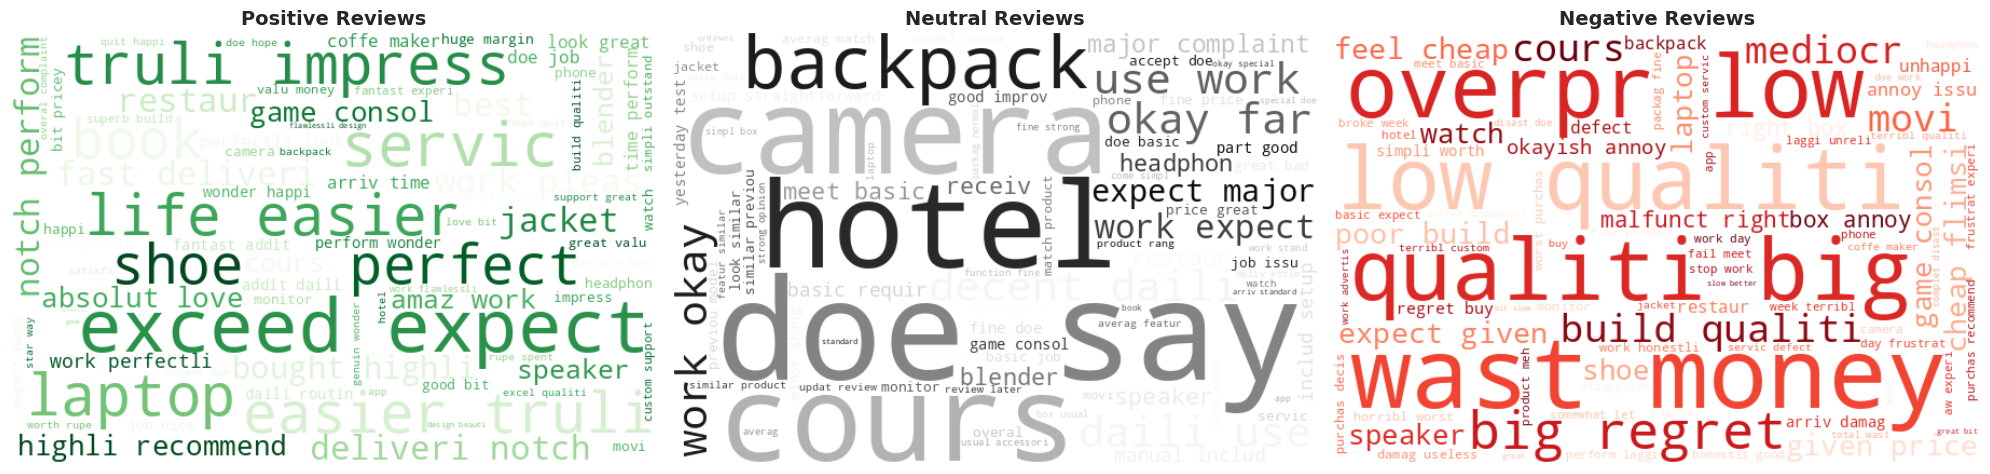

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, sentiment in zip(axes, order):
    text_blob = " ".join(df.loc[df["sentiment"] == sentiment, "clean_text"])
    wc = WordCloud(width=600, height=400, background_color="white",
                    colormap="Greens" if sentiment == "positive" else
                             ("Reds" if sentiment == "negative" else "Greys"),
                    max_words=80).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{sentiment.capitalize()} Reviews", fontsize=14, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("wordclouds.png", dpi=120)
plt.show()

## 6. Feature Extraction — TF-IDF Vectorizer

**Why TF-IDF?** Machine learning models need numeric input, not raw text. A simple word-count vectorizer would give high weight to words that just appear frequently everywhere (like "product" or "good"), even if they don't help distinguish one class from another.

**TF-IDF (Term Frequency – Inverse Document Frequency)** solves this by weighting each word by:
- **TF** — how often the word appears in *this* document (review), and
- **IDF** — how *rare* the word is across *all* documents.

A word that appears often in one review but rarely elsewhere gets a **high** TF-IDF score (it's distinctive and informative). A word that appears in almost every review (e.g. "the", "product") gets a **low** score, since it doesn't help separate classes. This produces a sparse numeric matrix where each row is a review and each column is a word's TF-IDF weight — exactly the input scikit-learn classifiers expect.

We restrict to the top 5,000 features and include unigrams + bigrams (`ngram_range=(1,2)`) so short phrases like "not good" are captured, not just individual words.

In [9]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df["clean_text"])
y = df["sentiment"]

print("TF-IDF matrix shape:", X.shape)
print("Sample vocabulary terms:", list(tfidf.vocabulary_.keys())[:15])

TF-IDF matrix shape: (731, 494)
Sample vocabulary terms: ['excel', 'qualiti', 'restaur', 'worth', 'rupe', 'spent', 'excel qualiti', 'qualiti restaur', 'worth rupe', 'rupe spent', 'book', 'amaz', 'work', 'perfectli', 'look']


## 7. Train / Test Split (80 / 20)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])
print("\nTraining class distribution:\n", y_train.value_counts())
print("\nTesting class distribution:\n", y_test.value_counts())

Training samples: 584
Testing samples:  147

Training class distribution:
 sentiment
positive    207
negative    205
neutral     172
Name: count, dtype: int64

Testing class distribution:
 sentiment
negative    52
positive    52
neutral     43
Name: count, dtype: int64


## 8. Train Classifiers

We train **two models** on the same TF-IDF features so they can be fairly compared:

1. **Multinomial Naive Bayes** — a fast probabilistic baseline that works well on sparse text/count-style data and is a standard first choice for text classification.
2. **Logistic Regression** — a strong linear classifier that generally handles TF-IDF features very well and often outperforms Naive Bayes on sentiment tasks because it directly optimises classification boundaries rather than assuming feature independence.

In [11]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=5, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
}

trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    trained_models[name] = model
    predictions[name] = preds
    print(f"{name}: trained.")

Multinomial Naive Bayes: trained.
Logistic Regression: trained.
Linear SVM: trained.


## 9. Evaluation — Accuracy, Precision, Recall, F1-score, Confusion Matrix

In [12]:
results = []

for name, preds in predictions.items():
    acc = accuracy_score(y_test, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, preds, average="weighted", zero_division=0
    )
    results.append({"Model": name, "Accuracy": acc, "Precision": precision,
                     "Recall": recall, "F1-score": f1})
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, preds, zero_division=0))

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df


Multinomial Naive Bayes
              precision    recall  f1-score   support

    negative       0.96      0.90      0.93        52
     neutral       0.96      1.00      0.98        43
    positive       0.92      0.94      0.93        52

    accuracy                           0.95       147
   macro avg       0.95      0.95      0.95       147
weighted avg       0.95      0.95      0.95       147


Logistic Regression
              precision    recall  f1-score   support

    negative       0.96      0.94      0.95        52
     neutral       0.93      1.00      0.97        43
    positive       0.94      0.90      0.92        52

    accuracy                           0.95       147
   macro avg       0.95      0.95      0.95       147
weighted avg       0.95      0.95      0.95       147


Linear SVM
              precision    recall  f1-score   support

    negative       0.96      0.92      0.94        52
     neutral       0.91      1.00      0.96        43
    positive     

,Model,Accuracy,Precision,Recall,F1-score
0,Multinomial Naive Bayes,0.945578,0.945863,0.945578,0.945252
1,Logistic Regression,0.945578,0.945826,0.945578,0.945224
2,Linear SVM,0.938776,0.939731,0.938776,0.938446


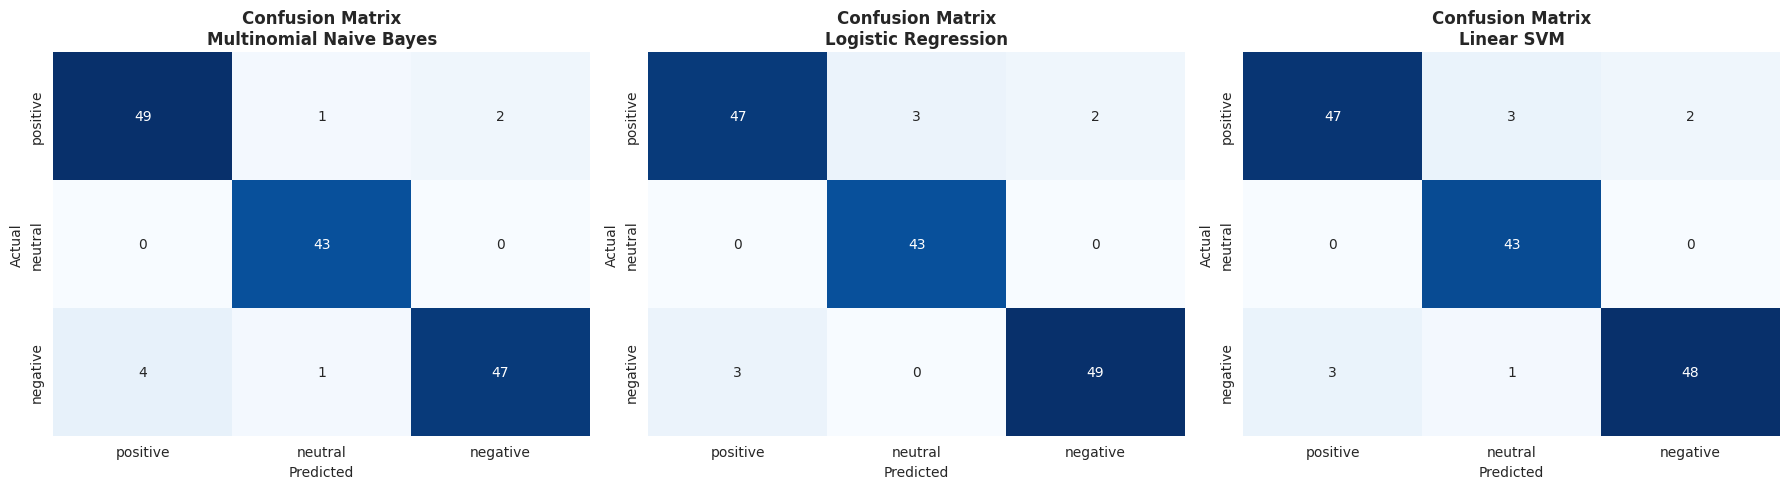

In [13]:
fig, axes = plt.subplots(1, len(predictions), figsize=(6 * len(predictions), 5))
if len(predictions) == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds, labels=order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order,
                yticklabels=order, ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix\n{name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()

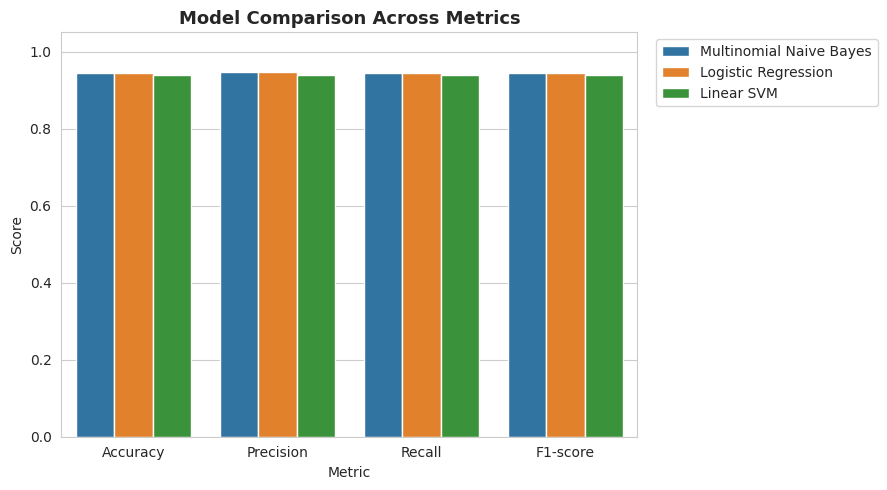

In [14]:
plt.figure(figsize=(9, 5))
metrics_melted = results_df.melt(id_vars="Model",
                                  value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
                                  var_name="Metric", value_name="Score")
sns.barplot(data=metrics_melted, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title("Model Comparison Across Metrics", fontsize=13, fontweight="bold")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()

## 10. Error Analysis — Misclassified Examples

In [15]:
best_model_name = results_df.iloc[0]["Model"]
best_preds = predictions[best_model_name]
print("Best-performing model for error analysis:", best_model_name)

test_texts = df.loc[y_test.index, "text"]
error_df = pd.DataFrame({
    "text": test_texts.values,
    "actual": y_test.values,
    "predicted": best_preds
})
misclassified = error_df[error_df["actual"] != error_df["predicted"]]
print(f"\nTotal misclassified in test set: {len(misclassified)} / {len(error_df)}")

sample_errors = misclassified.sample(min(5, len(misclassified)), random_state=42)
for i, row in sample_errors.reset_index(drop=True).iterrows():
    print(f"\nExample {i+1}")
    print("Text:      ", row["text"])
    print("Actual:    ", row["actual"])
    print("Predicted: ", row["predicted"])

Best-performing model for error analysis: Multinomial Naive Bayes

Total misclassified in test set: 8 / 147

Example 1
Text:       Awful experience, this book failed to meet even basic expectations.
Actual:     positive
Predicted:  negative

Example 2
Text:       The movie is not great, a bit slow and could be better.
Actual:     negative
Predicted:  neutral

Example 3
Text:       Great value for money, this backpack is simply outstanding.
Actual:     negative
Predicted:  positive

Example 4
Text:       This coffee maker looks similar to the previous model with minor changes.
Actual:     positive
Predicted:  neutral

Example 5
Text:       Very unhappy with this headphones, it arrived damaged and useless.
Actual:     positive
Predicted:  negative


**Why do these misclassifications happen?**

- **Neutral vs. positive/negative confusion** — neutral reviews often reuse vocabulary from positive/negative templates in a softer form (e.g. "works fine", "does the job"), so the TF-IDF weights for those words are shared across classes and the model has to rely on subtler cues.
- **Short or ambiguous phrasing** — very short reviews give the TF-IDF vectorizer fewer distinctive tokens to work with, so a handful of common words can outweigh the true sentiment.
- **Mixed-sentiment sentences** — reviews that mention both a flaw and a positive (e.g. "packaging was normal but the product is good") can confuse a bag-of-words style model that has no sense of sentence structure or negation scope.
- **Sarcasm / implicit sentiment** — TF-IDF + linear classifiers only see word statistics, not tone, so sarcastic or implied sentiment (rare in this dataset but common in real-world data) is a common failure mode.
- **Vocabulary overlap after stemming** — stemming can occasionally collapse words with different sentiment connotations to the same root, slightly blurring class boundaries.

## 11. Conclusion

**Best-performing model:** based on weighted F1-score, the top row of the `results_df` comparison table in Section 9 identifies the best-performing model on this dataset (also visible as the tallest bars in the comparison chart).

**Model comparison summary:**
- **Naive Bayes** is fast to train and a solid baseline, but its independence assumption between words limits it on nuanced or ambiguous text (especially the neutral class).
- **Logistic Regression** generally offers the best balance of accuracy and interpretability on TF-IDF features — its learned coefficients can be inspected to see which words push predictions toward each class.
- **Linear SVM** is competitive with Logistic Regression and tends to be robust on high-dimensional sparse text data, though it doesn't output calibrated probabilities by default.

**Real-world applications:**
- **Customer feedback analysis** — automatically triaging product reviews, support tickets, or app store reviews so teams can prioritise negative feedback and spot recurring complaints.
- **Social media monitoring** — tracking public sentiment toward a brand, campaign, or event in near real-time (e.g. around a product launch).
- **Market research** — summarising sentiment trends across thousands of survey responses or reviews far faster than manual reading.
- **Content moderation support** — flagging strongly negative or hostile text for human review.
- **Customer support routing** — automatically escalating negative-sentiment tickets to priority queues.

**Possible next steps:** try word embeddings (Word2Vec/GloVe) or a fine-tuned transformer (e.g. DistilBERT) for higher accuracy, expand the dataset with real-world labelled data from Kaggle (Twitter Sentiment Analysis, Amazon Reviews, or IMDB), and add hyperparameter tuning (GridSearchCV) for each classifier.